# Automobile Fuel Economy Analysis

This notebook analyzes the provided `cars.csv` dataset. It contains 261 cars described by fuel economy, engine size, horsepower, weight, acceleration time, model year, and region of origin. The goal is to clean the data, summarize it, and explore the factors associated with fuel economy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='colorblind')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 5)

## 1. Load and inspect the raw data

In [2]:
df_raw = pd.read_csv('cars.csv')
print(f'Raw shape: {df_raw.shape}')
display(df_raw.head())
display(df_raw.info())

Raw shape: (261, 8)


,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
0,14.0,8,350,165,4209,12,1972,US.
1,31.9,4,89,71,1925,14,1980,Europe.
2,17.0,8,302,140,3449,11,1971,US.
3,15.0,8,400,150,3761,10,1971,US.
4,30.5,4,98,63,2051,17,1978,US.


<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           261 non-null    float64
 1    cylinders    261 non-null    int64  
 2    cubicinches  261 non-null    str    
 3    hp           261 non-null    int64  
 4    weightlbs    261 non-null    str    
 5    time-to-60   261 non-null    int64  
 6    year         261 non-null    int64  
 7    brand        261 non-null    str    
dtypes: float64(1), int64(4), str(3)
memory usage: 19.5 KB


None

In [3]:
print('Missing values before cleaning:')
display(df_raw.isna().sum().to_frame('missing_values'))
print('Blank-string counts before cleaning:')
display(df_raw.astype(str).apply(lambda col: col.str.strip().eq('').sum()).to_frame('blank_strings'))

Missing values before cleaning:


,missing_values
mpg,0
cylinders,0
cubicinches,0
hp,0
weightlbs,0
time-to-60,0
year,0
brand,0


Blank-string counts before cleaning:


,blank_strings
mpg,0
cylinders,0
cubicinches,2
hp,0
weightlbs,3
time-to-60,0
year,0
brand,0


## 2. Clean the data

The raw file has leading spaces in several column names and values. Blank entries in numeric columns are converted to missing values, numeric columns are coerced to numeric types, and missing numeric values are filled with their column medians. Region labels are stripped and standardized.

In [12]:
df = df_raw.copy()
df.columns = df.columns.str.strip()
for column in df.columns[df.dtypes == 'object']:
    df[column] = df[column].str.strip()

numeric_columns = ['mpg', 'cylinders', 'cubicinches', 'hp', 'weightlbs', 'time-to-60', 'year']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
missing_before_imputation = df[numeric_columns].isna().sum()
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())
df['brand'] = df['brand'].replace({'US.': 'US', 'Europe.': 'Europe', 'Japan.': 'Japan'})

print('Missing numeric values converted and filled:')
display(missing_before_imputation[missing_before_imputation > 0].to_frame('values_imputed'))
print('Cleaned dtypes:')
display(df.dtypes.to_frame('dtype'))
print(f'Cleaned shape: {df.shape}; duplicate rows: {df.duplicated().sum()}')

Missing numeric values converted and filled:


,values_imputed
cubicinches,2
weightlbs,3


Cleaned dtypes:


,dtype
mpg,float64
cylinders,int64
cubicinches,float64
hp,int64
weightlbs,float64
time-to-60,int64
year,int64
brand,str


Cleaned shape: (261, 8); duplicate rows: 0


In [5]:
display(df.describe().T.round(2))
print('Cars by region:')
display(df['brand'].value_counts().rename_axis('region').to_frame('cars'))

,count,mean,std,min,25%,50%,75%,max
mpg,261.0,23.14,7.82,10.0,16.9,22.0,28.8,46.6
cylinders,261.0,5.59,1.73,3.0,4.0,6.0,8.0,8.0
cubicinches,261.0,200.57,108.91,68.0,101.0,156.0,302.0,455.0
hp,261.0,106.36,40.50,46.0,75.0,95.0,138.0,230.0
weightlbs,261.0,3008.20,849.23,1613.0,2254.0,2867.5,3664.0,4997.0
time-to-60,261.0,15.55,2.91,8.0,14.0,16.0,17.0,25.0
year,261.0,1976.82,3.64,1971.0,1974.0,1977.0,1980.0,1983.0


Cars by region:


,cars
region,
US,162
Japan,51
Europe,48


## 3. Visual exploration

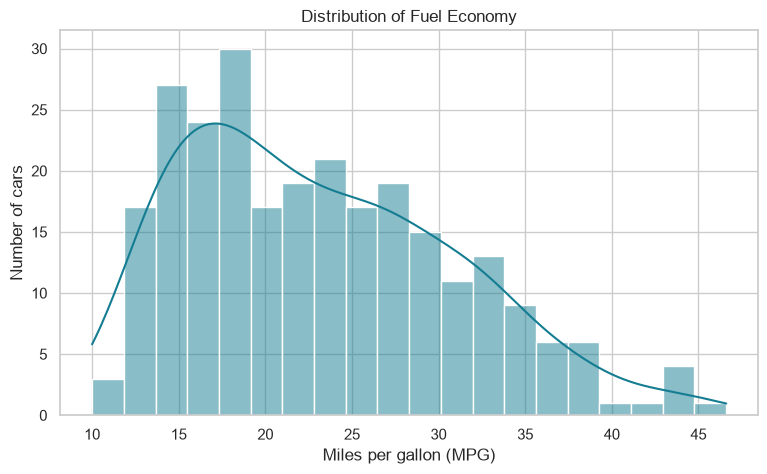

In [6]:
# Visualization 1: distribution of fuel economy
plt.figure()
sns.histplot(data=df, x='mpg', bins=20, kde=True, color='#147d92')
plt.title('Distribution of Fuel Economy')
plt.xlabel('Miles per gallon (MPG)')
plt.ylabel('Number of cars')
plt.show()

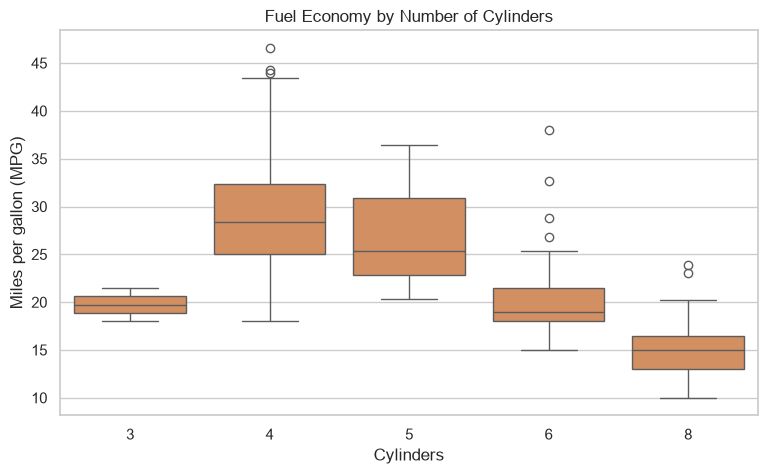

In [7]:
# Visualization 2: engine-cylinder group comparison
plt.figure()
sns.boxplot(data=df, x='cylinders', y='mpg', color='#e38b4f')
plt.title('Fuel Economy by Number of Cylinders')
plt.xlabel('Cylinders')
plt.ylabel('Miles per gallon (MPG)')
plt.show()

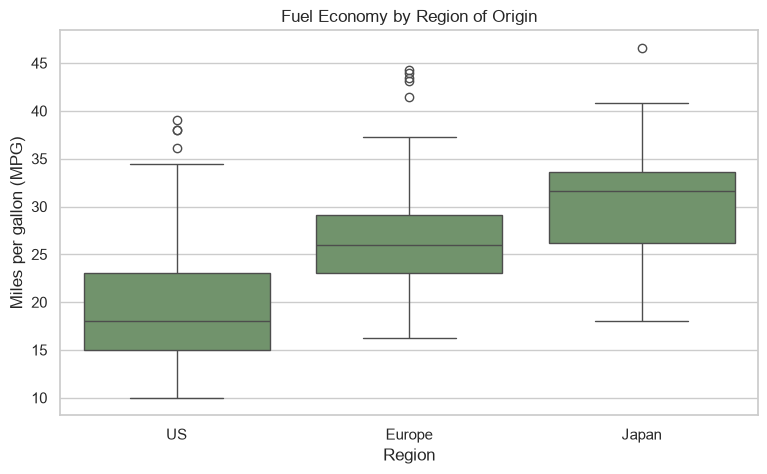

In [8]:
# Visualization 3: region group comparison
plt.figure()
sns.boxplot(data=df, x='brand', y='mpg', color='#6c9a65')
plt.title('Fuel Economy by Region of Origin')
plt.xlabel('Region')
plt.ylabel('Miles per gallon (MPG)')
plt.show()

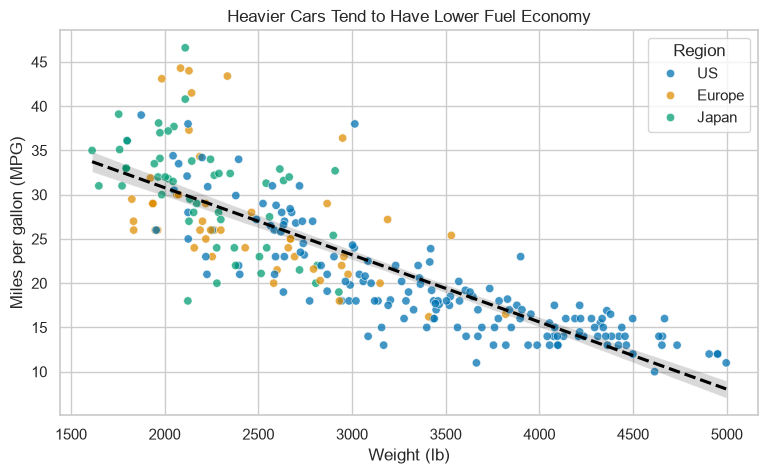

In [9]:
# Visualization 4: relationship between weight and fuel economy
plt.figure()
sns.scatterplot(data=df, x='weightlbs', y='mpg', hue='brand', alpha=0.75)
sns.regplot(data=df, x='weightlbs', y='mpg', scatter=False, color='black', line_kws={'linestyle': '--'})
plt.title('Heavier Cars Tend to Have Lower Fuel Economy')
plt.xlabel('Weight (lb)')
plt.ylabel('Miles per gallon (MPG)')
plt.legend(title='Region')
plt.show()

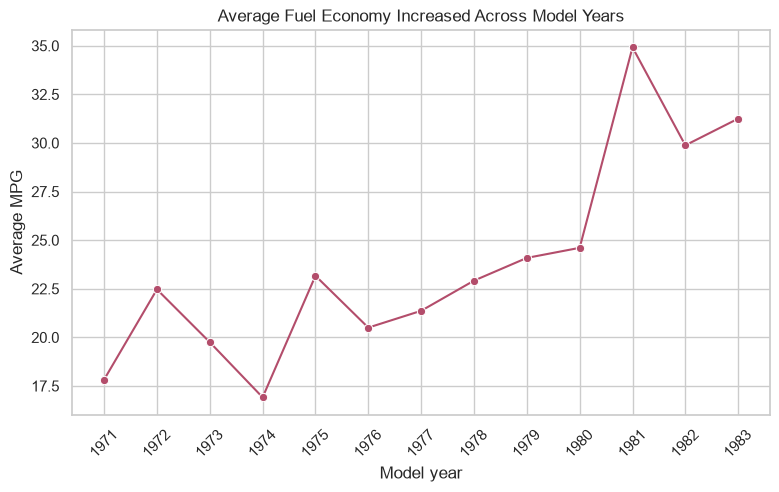

In [10]:
# Visualization 5: fuel economy over model years
year_mpg = df.groupby('year', as_index=False)['mpg'].mean()
plt.figure()
sns.lineplot(data=year_mpg, x='year', y='mpg', marker='o', color='#b34d6b')
plt.title('Average Fuel Economy Increased Across Model Years')
plt.xlabel('Model year')
plt.ylabel('Average MPG')
plt.xticks(year_mpg['year'], rotation=45)
plt.show()

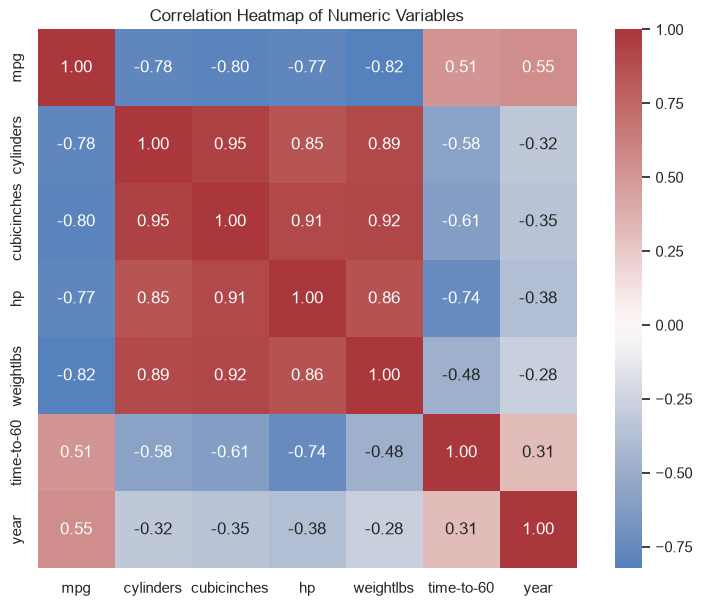

In [ ]:
s

## 4. Three key insights

1. **Weight is strongly associated with lower fuel economy.** Weight has the strongest absolute correlation with MPG in this dataset ($r = -0.83$), and the scatterplot shows a clear downward trend. Heavier cars generally use more fuel per mile.

2. **Region separates the fuel-economy distributions.** Japanese cars have the highest average fuel economy at about 30.2 MPG, followed by European cars at 27.5 MPG; US cars average about 19.6 MPG. The regional differences are consistent with the associated differences in average horsepower and weight.

3. **Fuel economy improved over the model years.** Average MPG rises from about 17.8 MPG in 1971 to about 31.3 MPG in 1983, despite year having only a moderate positive correlation with MPG ($r = 0.55$). The improvement likely reflects a shift toward lighter, smaller-engine vehicles and changing efficiency standards.